<a href="https://colab.research.google.com/github/tasneem1865/Deep-Learning-Lab/blob/main/practical_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 23070521162 - Tasneem Sadikot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
df = pd.read_csv('Housing.csv')

print(df.head())
print('\nShape:', df.shape)
print('\nColumns:', list(df.columns))


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Shape: (545, 13)

Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'gues

In [ ]:
X = df.drop(columns=['price'])
y = df['price']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print('\nTraining shape:', X_train.shape)
print('Testing shape:', X_test.shape)



Training shape: (436, 20)
Testing shape: (109, 20)


In [ ]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)


In [ ]:
pred = model.predict(X_test, verbose=0).ravel()

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print('MAE:', round(mae, 2))
print('MSE:', round(mse, 2))
print('RMSE:', round(rmse, 2))


MAE: 997066.94
MSE: 1859185934336.0
RMSE: 1363519.69


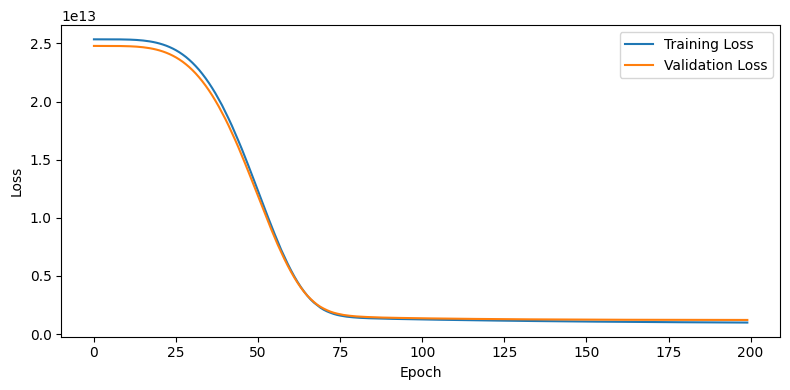

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.regularizers import l1, l2

# Define the regularized model
regularized_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)), # L2 regularization
    Dropout(0.3), # Dropout layer
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)), # L2 regularization
    Dropout(0.3), # Dropout layer
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)), # L2 regularization
    Dropout(0.3), # Dropout layer
    Dense(1)
])

# Compile the regularized model
regularized_model.compile(optimizer='adam', loss='mean_squared_error')

# Define Early Stopping callback
early_stop_regularized = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the regularized model
history_regularized = regularized_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop_regularized],
    verbose=0
)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred_regularized = regularized_model.predict(X_test, verbose=0).ravel()

mae_regularized = mean_absolute_error(y_test, pred_regularized)
mse_regularized = mean_squared_error(y_test, pred_regularized)
rmse_regularized = np.sqrt(mse_regularized)

print('Regularized Model MAE:', round(mae_regularized, 2))
print('Regularized Model MSE:', round(mse_regularized, 2))
print('Regularized Model RMSE:', round(rmse_regularized, 2))

print('\nBaseline Model MAE:', round(mae, 2))
print('Baseline Model MSE:', round(mse, 2))
print('Baseline Model RMSE:', round(rmse, 2))

Regularized Model MAE: 1096055.38
Regularized Model MSE: 2235133853696.0
Regularized Model RMSE: 1495036.41

Baseline Model MAE: 997066.94
Baseline Model MSE: 1859185934336.0
Baseline Model RMSE: 1363519.69


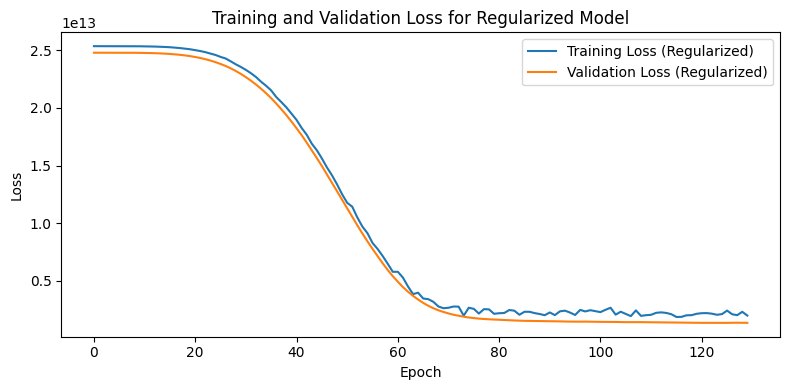

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history_regularized.history['loss'], label='Training Loss (Regularized)')
plt.plot(history_regularized.history['val_loss'], label='Validation Loss (Regularized)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss for Regularized Model')
plt.tight_layout()
plt.show()

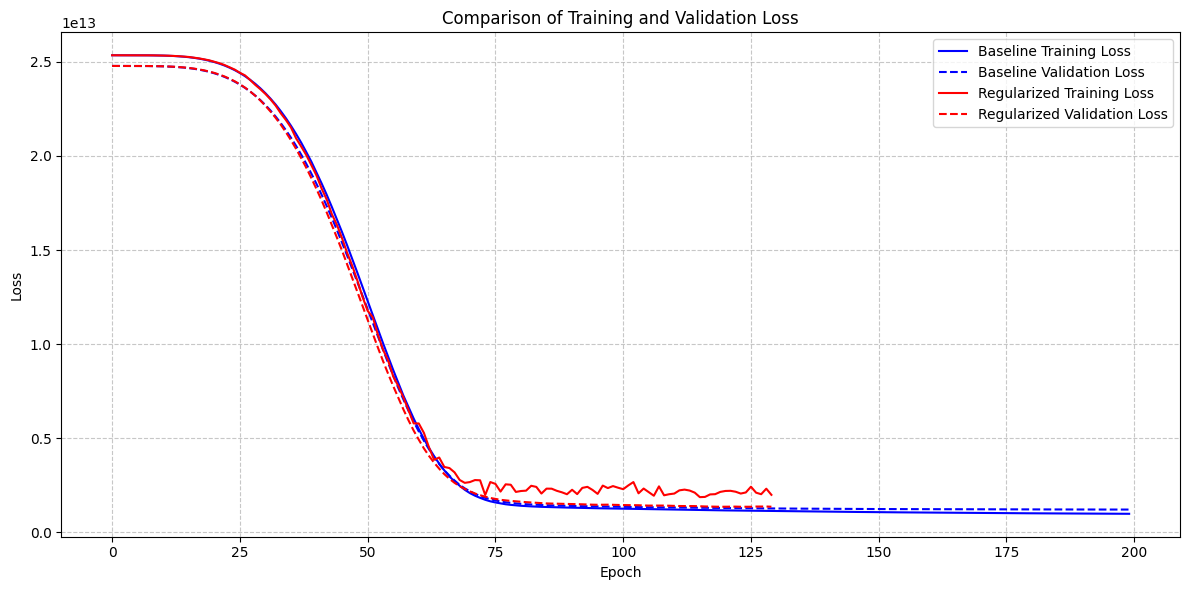

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot Baseline Model Loss
plt.plot(history.history['loss'], label='Baseline Training Loss', color='blue', linestyle='-')
plt.plot(history.history['val_loss'], label='Baseline Validation Loss', color='blue', linestyle='--')

# Plot Regularized Model Loss
plt.plot(history_regularized.history['loss'], label='Regularized Training Loss', color='red', linestyle='-')
plt.plot(history_regularized.history['val_loss'], label='Regularized Validation Loss', color='red', linestyle='--')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Comparison of Training and Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
metrics_data = {
    'Model': ['Baseline Model', 'Regularized Model'],
    'MAE': [mae, mae_regularized],
    'MSE': [mse, mse_regularized],
    'RMSE': [rmse, rmse_regularized]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df = metrics_df.round(2)
display(metrics_df)

,Model,MAE,MSE,RMSE
0,Baseline Model,997066.94,1.859186e+12,1363519.69
1,Regularized Model,1096055.38,2.235134e+12,1495036.41
